In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
import time
import os
from datetime import datetime

In [2]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.pipeline import Pipeline

# Scikit-learn — modeli
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.utils.class_weight import compute_class_weight

# Scikit-learn — metrike
from sklearn.metrics import (
    roc_auc_score, classification_report, confusion_matrix,
    roc_curve, precision_recall_curve, average_precision_score,
    f1_score, accuracy_score, precision_score, recall_score
)
from sklearn.inspection import permutation_importance

In [3]:
# Konfiguracija
warnings.filterwarnings('ignore')
np.random.seed(42)
os.makedirs('plots', exist_ok=True)

# Stil vizualizacija
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.dpi': 100,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'figure.facecolor': 'white'
})

COLORS = {
    'fraud':     '#e74c3c',
    'legit':     '#2ecc71',
    'primary':   '#3498db',
    'secondary': '#9b59b6',
    'warning':   '#f39c12',
    'dark':      '#2c3e50'
}

print('Sve biblioteke uspesno uvezene!')
print(f'Datum pokretanja: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')
print(f'NumPy: {np.__version__} | Pandas: {pd.__version__} | Scikit-learn: {__import__("sklearn").__version__}')

Sve biblioteke uspesno uvezene!
Datum pokretanja: 2026-06-17 20:00:54
NumPy: 2.3.2 | Pandas: 2.3.2 | Scikit-learn: 1.7.1


In [5]:
df = pd.read_csv('csvs\creditcard.csv')

print(f'Dimenzije: {df.shape[0]:,} transakcija x {df.shape[1]} atributa')
print(f'Memorija: {df.memory_usage(deep=True).sum()/1024**2:.1f} MB')
print(f'Nullovi: {df.isnull().sum().sum()}')

print('\nPrvih 5 redova:')
df.head()

Dimenzije: 284,807 transakcija x 31 atributa
Memorija: 67.4 MB
Nullovi: 0

Prvih 5 redova:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [6]:
# OSNOVNA STATISTIKA
fraud = df[df['Class'] == 1]
legit = df[df['Class'] == 0]

print('=== DISTRIBUCIJA KLASA ===')
print(f'Legitimne transakcije: {len(legit):>7,}  ({len(legit)/len(df)*100:.3f}%)')
print(f'Prevare:               {len(fraud):>7,}  ({len(fraud)/len(df)*100:.3f}%)')
print(f'Ukupno:                {len(df):>7,}')
print(f'Odnos klasa:           {len(legit)/len(fraud):.0f}:1  (legitimne:prevare)')

print('\n=== IZNOSI TRANSAKCIJA ===')
print(f'Prosecni iznos — Legitimne: {legit["Amount"].mean():.2f} EUR')
print(f'Prosecni iznos — Prevare:   {fraud["Amount"].mean():.2f} EUR')
print(f'Max iznos — Legitimne:      {legit["Amount"].max():.2f} EUR')
print(f'Max iznos — Prevare:        {fraud["Amount"].max():.2f} EUR')

print('\n=== VREMENSKI RASPON ===')
print(f'Trajanje perioda: {df["Time"].max()/3600:.1f} sati (~2 dana)')
print(f'Broj transakcija po satu: {len(df)/(df["Time"].max()/3600):.0f}')

df.describe().round(3)

=== DISTRIBUCIJA KLASA ===
Legitimne transakcije: 284,315  (99.827%)
Prevare:                   492  (0.173%)
Ukupno:                284,807
Odnos klasa:           578:1  (legitimne:prevare)

=== IZNOSI TRANSAKCIJA ===
Prosecni iznos — Legitimne: 88.29 EUR
Prosecni iznos — Prevare:   122.21 EUR
Max iznos — Legitimne:      25691.16 EUR
Max iznos — Prevare:        2125.87 EUR

=== VREMENSKI RASPON ===
Trajanje perioda: 48.0 sati (~2 dana)
Broj transakcija po satu: 5934


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,...,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000
mean,94813.860,0.000,0.000,-0.000,0.000,0.000,0.000,-0.000,0.000,-0.000,...,0.000,-0.000,0.000,0.000,0.000,0.000,-0.000,-0.000,88.350,0.002
std,47488.146,1.959,1.651,1.516,1.416,1.380,1.332,1.237,1.194,1.099,...,0.735,0.726,0.624,0.606,0.521,0.482,0.404,0.330,250.120,0.042
min,0.000,-56.408,-72.716,-48.326,-5.683,-113.743,-26.161,-43.557,-73.217,-13.434,...,-34.830,-10.933,-44.808,-2.837,-10.295,-2.605,-22.566,-15.430,0.000,0.000
25%,54201.500,-0.920,-0.599,-0.890,-0.849,-0.692,-0.768,-0.554,-0.209,-0.643,...,-0.228,-0.542,-0.162,-0.355,-0.317,-0.327,-0.071,-0.053,5.600,0.000
50%,84692.000,0.018,0.065,0.180,-0.020,-0.054,-0.274,0.040,0.022,-0.051,...,-0.029,0.007,-0.011,0.041,0.017,-0.052,0.001,0.011,22.000,0.000
75%,139320.500,1.316,0.804,1.027,0.743,0.612,0.399,0.570,0.327,0.597,...,0.186,0.529,0.148,0.440,0.351,0.241,0.091,0.078,77.165,0.000
max,172792.000,2.455,22.058,9.383,16.875,34.802,73.302,120.589,20.007,15.595,...,27.203,10.503,22.528,4.585,7.520,3.517,31.612,33.848,25691.160,1.000


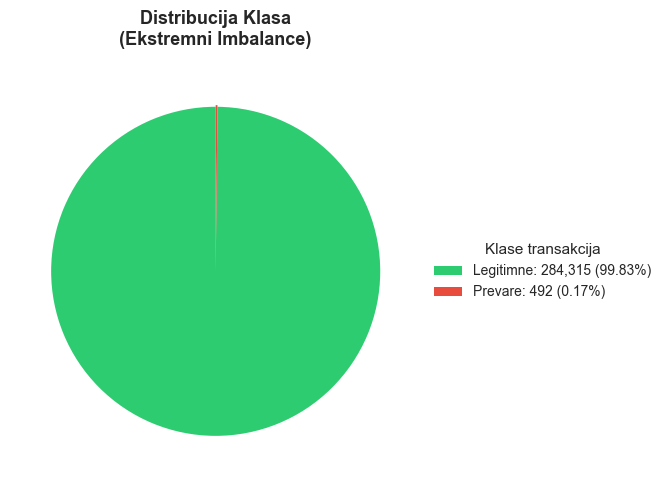

In [7]:
fraud = df[df['Class'] == 1]
legit = df[df['Class'] == 0]

fig, ax = plt.subplots(figsize=(7, 5))

sizes = [len(legit), len(fraud)]
colors = [COLORS['legit'], COLORS['fraud']]

wedges, _ = ax.pie(
    sizes,
    colors=colors,
    startangle=90,
    explode=(0, 0.01),
    shadow=False,
    wedgeprops=dict(edgecolor='none')
)

# Tačni podaci u legendi sa strane
total = len(df)
labels = [
    f"Legitimne: {len(legit):,} ({len(legit)/total*100:.2f}%)",
    f"Prevare: {len(fraud):,} ({len(fraud)/total*100:.2f}%)"
]

ax.legend(
    wedges, labels,
    title="Klase transakcija",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1),
    fontsize=10,
    title_fontsize=11,
    frameon=False
)

ax.set_title('Distribucija Klasa\n(Ekstremni Imbalance)', fontweight='bold', fontsize=13, pad=15)

plt.tight_layout()
plt.show()

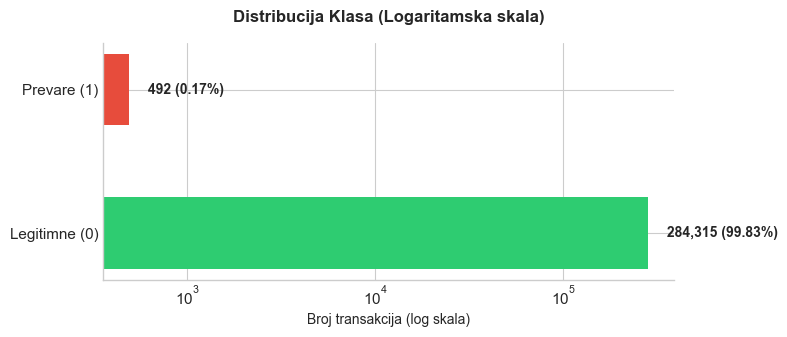

In [8]:
fig, ax = plt.subplots(figsize=(8, 3.5))

classes = ['Legitimne (0)', 'Prevare (1)']
counts = [len(legit), len(fraud)]
colors = [COLORS['legit'], COLORS['fraud']]

bars = ax.barh(classes, counts, color=colors, edgecolor='none', height=0.5)

# Postavljamo logaritamsku skalu na X osi da se prevare lepo vide
ax.set_xscale('log')

# Dodajemo tačne tekstualne vrednosti i procente odmah pored traka
total = len(df)
for bar, count in zip(bars, counts):
    percentage = (count / total) * 100
    # Mala matematika za pomeranje teksta udesno na log skali
    ax.text(
        count * 1.2,
        bar.get_y() + bar.get_height()/2,
        f' {count:,} ({percentage:.2f}%)',
        va='center',
        ha='left',
        fontweight='bold',
        fontsize=10
    )

# Sređujemo ivice grafikona (skidamo gornju i desnu da izgleda čistije)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Naslov i labele
ax.set_title('Distribucija Klasa (Logaritamska skala)', fontweight='bold', fontsize=12, pad=15)
ax.set_xlabel('Broj transakcija (log skala)', fontsize=10)

plt.tight_layout()

# Kod sebe koristi plt.show()
plt.show()

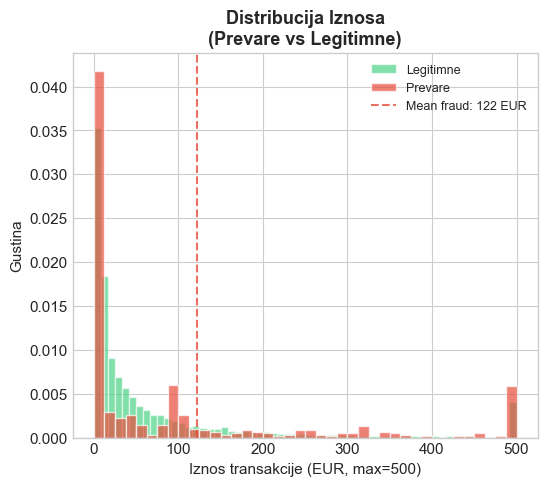

In [9]:
fig, ax = plt.subplots(figsize=(6, 5))

ax.hist(legit['Amount'].clip(upper=500), bins=60,
        alpha=0.6, color=COLORS['legit'], label='Legitimne', density=True)
ax.hist(fraud['Amount'].clip(upper=500), bins=40,
        alpha=0.7, color=COLORS['fraud'], label='Prevare', density=True)
ax.set_xlabel('Iznos transakcije (EUR, max=500)')
ax.set_ylabel('Gustina')
ax.set_title('Distribucija Iznosa\n(Prevare vs Legitimne)', fontweight='bold')

mean_fraud = fraud['Amount'].mean()
ax.axvline(mean_fraud, color=COLORS['fraud'], ls='--',
           alpha=0.8, label=f'Mean fraud: {mean_fraud:.0f} EUR')
ax.legend(fontsize=9)

plt.savefig('plots/fig1_3_amount_dist.png', bbox_inches='tight', dpi=150)
plt.show()

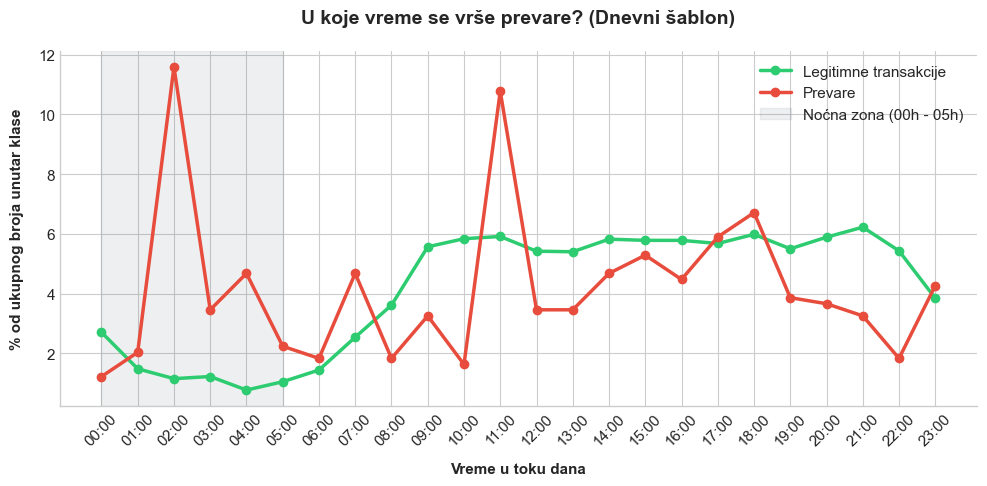

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# REŠENJE: Pretvaramo sekunde u cele sate (0-23) koristeći celobrojno deljenje (//)
# Ovo će grupisati sve transakcije unutar istog sata zajedno!
legit_hours = (legit['Time'] // 3600) % 24
fraud_hours = (fraud['Time'] // 3600) % 24

# Računamo procenat transakcija za svaki sat (od 0 do 23)
# Koristimo .reindex(range(24), fill_value=0) da osiguramo da imamo pokrivene sve sate
legit_by_hour = legit_hours.value_counts(normalize=True).reindex(range(24), fill_value=0).sort_index() * 100
fraud_by_hour = fraud_hours.value_counts(normalize=True).reindex(range(24), fill_value=0).sort_index() * 100

# Kreiramo grafikon - malo veći format za bolju čitljivost
fig, ax = plt.subplots(figsize=(10, 5))

# Crtamo glatke linije
ax.plot(legit_by_hour.index, legit_by_hour.values,
        color=COLORS['legit'], label='Legitimne transakcije', linewidth=2.5, marker='o')
ax.plot(fraud_by_hour.index, fraud_by_hour.values,
        color=COLORS['fraud'], label='Prevare', linewidth=2.5, marker='o')

# Blago senčimo noćnu zonu (od ponoći do 5 ujutru) da istaknemo kritičan period
ax.axvspan(0, 5, color='#2c3e50', alpha=0.08, label='Noćna zona (00h - 05h)')

# Podešavamo X osu da prikazuje sate elegantno
ax.set_xticks(range(0, 24))
ax.set_xticklabels([f'{h:02d}:00' for h in range(0, 24)], rotation=45)

# Skidamo gornji i desni okvir grafikona da izgleda modernije
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Labele i naslov
ax.set_xlabel('Vreme u toku dana', fontweight='bold', labelpad=10)
ax.set_ylabel('% od ukupnog broja unutar klase', fontweight='bold', labelpad=10)
ax.set_title('U koje vreme se vrše prevare? (Dnevni šablon)', fontweight='bold', fontsize=14, pad=20)

# Pozicioniramo legendu da ne smeta
ax.legend(loc='upper right', frameon=False)

plt.tight_layout()
plt.show()